## Demo of the walkability project's dataLoaders

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from walkability.dataset.dataloader import get_data_loaders, LABEL_MAP
import matplotlib.pyplot as plt
import numpy as np

: 

In [3]:
BASE_PATH = "/projects/dsci410_510/data/walkability_dataset/"

train_loader, val_loader, test_loader = get_data_loaders(
    base_path=BASE_PATH,
    name="all",
    batch_size=9 # small example
)

print(f"Train samples: {len(train_loader.dataset)}")
print(f"Val samples:   {len(val_loader.dataset)}")
print(f"Test samples:  {len(test_loader.dataset)}")

Train samples: 5078
Val samples:   1693
Test samples:  1693


/packages/miniconda-t2/20230523/envs/jupyter-cuda121-20230610/lib/python3.8/site-packages/torch/utils/data/dataloader.py:560: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
/packages/miniconda-t2/20230523/envs/jupyter-cuda121-20230610/lib/python3.8/site-packages/torch/utils/data/dataloader.py:560: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze i

In [4]:
images, labels = next(iter(train_loader))

# print the shape of the images and labels
print(f"Image batch shape: {images.shape}")  # (batch_size, 3, 224, 224)
print(f"Label batch shape: {labels.shape}")
print(f"Labels: {labels}") # labels: 0, 1, or 2 (for 3 classes)

Image batch shape: torch.Size([9, 3, 224, 224])
Label batch shape: torch.Size([9])
Labels: tensor([1, 2, 2, 0, 2, 2, 2, 0, 2])


### Plot the first batch of images

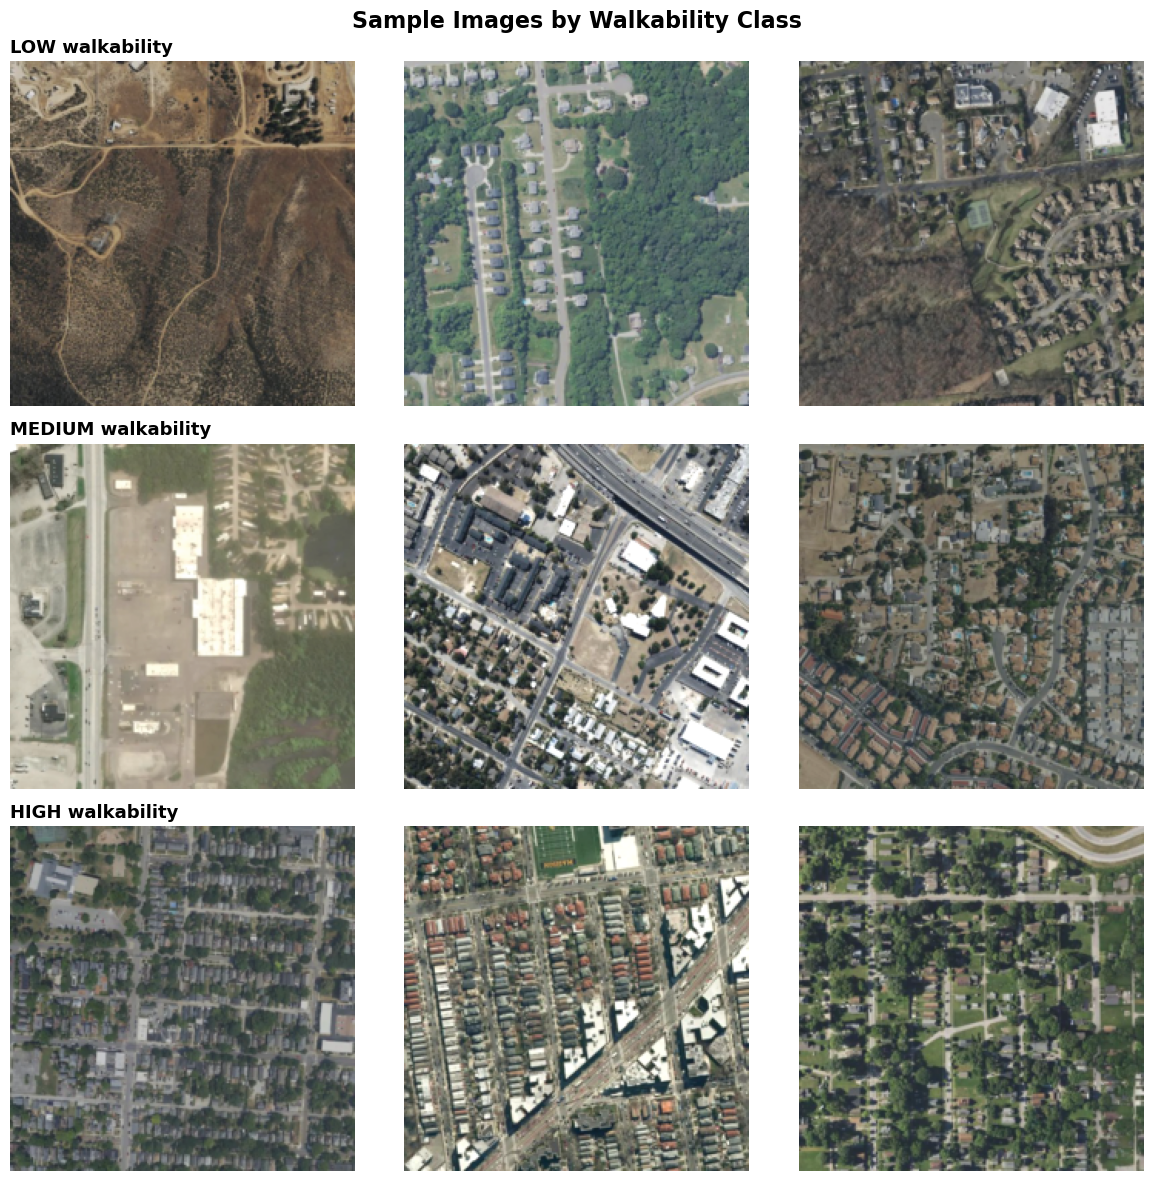

In [5]:
# undo ImageNet normalization for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def denormalize(imgs):
    imgs = imgs * std + mean
    imgs = (imgs * 255).clamp(0, 255).numpy().transpose(0, 2, 3, 1).astype('uint8')
    return imgs

INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}
SAMPLES_PER_CLASS = 3

fig, axes = plt.subplots(3, SAMPLES_PER_CLASS, figsize=(SAMPLES_PER_CLASS * 4, 12))
fig.suptitle("Sample Images by Walkability Class", fontsize=16, fontweight="bold")

for class_idx, class_name in enumerate(["low", "medium", "high"]):
    collected = []
    for imgs, lbls in train_loader:
        mask = lbls == LABEL_MAP[class_name]
        collected.append(imgs[mask])
        if sum(len(c) for c in collected) >= SAMPLES_PER_CLASS:
            break
    samples = denormalize(torch.cat(collected)[:SAMPLES_PER_CLASS])
    for col in range(SAMPLES_PER_CLASS):
        ax = axes[class_idx][col]
        ax.imshow(samples[col])
        ax.axis("off")
        if col == 0:
            ax.set_title(f"{class_name.upper()} walkability", fontsize=13, fontweight="bold", loc="left")

plt.tight_layout()
plt.show()